### 단축키 사용법
- 실행단축키
    - Ctrl + Enter
    - Shift + Enter
- 마크다운 변환
    - Ctrl + M + M
- 코드모드 변환
    - Ctrl + M + Y
- 아래셀 추가
    - Ctrl + M + B
- 위에셀 추가
    - Ctrl + M + A

### Machine Learning
- 기계(인공지능)가 데이터를 학습하여 특징을 추출하고 새로운 데이터를 예측하는 과정
### ML 종류
- 지도학습
    - 정답(label)이 있는 데이터를 학습
    - 분류 (범주형 정답), 회귀 (연속형 정답)
- 비지도학습
    - 정답(label)이 없는 데이터를 학습
- 강화학습
    - 보상을 받는 방향으로 학습

### BMI 예측하기
- 문제정의 : 500명의 키와 몸무게, 비만도를 Label로 매칭되어있는 데이터를 이용하여 비만도를 판단하는 모델을 만들어보자

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


- 구글 드라이브 마운트
```
%cd
```

In [ ]:
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [ ]:
# 현재 워크 디렉토리 확인
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [ ]:
data = pd.read_csv("./데이터/bmi_500.csv",index_col="Label")

In [ ]:
data

,Gender,Height,Weight
Label,,,
Obesity,Male,174,96
Normal,Male,189,87
Obesity,Female,185,110
Overweight,Female,195,104
Overweight,Male,149,61
...,...,...,...
Extreme Obesity,Female,150,153
Obesity,Female,184,121
Extreme Obesity,Female,141,136


- X : Feature, 독립변수
- Y : Label, 종속변수

### 머신러닝 학습과정
- 모델 정의
- 모델 학습
- 모델 예측
- 모델 평가


In [ ]:
## 데이터 분리
## 데이터 크기
data.shape

(500, 3)

In [ ]:
# 정답 데이터 확인
data.index.unique()
# class가 6개인 다중분류
# 6개중 1개를 예측하는 모델

Index(['Obesity', 'Normal', 'Overweight', 'Extreme Obesity', 'Weak',
       'Extremely Weak'],
      dtype='object', name='Label')

- 데이터 분리
    - 문제(X), 정답(y)
    - 문제 : Height,Weight
    - 정답 : Label(index)

In [ ]:
data.iloc[[:,1:]]

SyntaxError: invalid syntax (ipython-input-627845329.py, line 1)

In [ ]:
X = data.iloc[:,1:]

In [ ]:
X

,Height,Weight
Label,,
Obesity,174,96
Normal,189,87
Obesity,185,110
Overweight,195,104
Overweight,149,61
...,...,...
Extreme Obesity,150,153
Obesity,184,121
Extreme Obesity,141,136


In [ ]:
y = data.index

In [ ]:
y

Index(['Obesity', 'Normal', 'Obesity', 'Overweight', 'Overweight',
       'Overweight', 'Extreme Obesity', 'Extreme Obesity', 'Overweight',
       'Obesity',
       ...
       'Normal', 'Extreme Obesity', 'Extremely Weak', 'Weak',
       'Extreme Obesity', 'Extreme Obesity', 'Obesity', 'Extreme Obesity',
       'Extreme Obesity', 'Extreme Obesity'],
      dtype='object', name='Label', length=500)

In [ ]:
# 머신러닝 학습과 예측, 평가를 위해 500개의 데이터 7:3으로 분리
# 학습용(train) 데이터 7, 평가용(test) 데이터 3
# X_train, y_train,X_test,y_test로 분리
X_train = X.iloc[:350]
y_train = y[:350]

In [ ]:
y.iloc[:350]

AttributeError: 'Index' object has no attribute 'iloc'

- y는 데이터 프레임이 아니라 iloc 사용 X

In [ ]:
X_test = X.iloc[350:]
y_test = y[350:]

In [ ]:
X_train.shape

(350, 2)

In [ ]:
y_train.shape

(350,)

In [ ]:
X_test.shape

(150, 2)

In [ ]:
y_test.shape

(150,)

### ML Library sklearn(사이킷런)

1. 모델 정의하기

In [ ]:
# 이미 알고리즘이 설계 되어있음
# 모델을 불러와서 정의
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 모델 객체 생성 (정의)
knn_model = KNeighborsClassifier()

2. 모델 학습하기

In [ ]:
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

3. 모델 예측

In [ ]:
y_pred = knn_model.predict(X_test)

4.모델 평가
- 예측한 결과와 실제결과를 비교하여 얼마나 잘 맞췄는지 확인
- 전체 데이터에서 맞춘 비율 -> accuracy

In [ ]:
# 정확도 측정 도구
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.9066666666666666

In [ ]:
knn_model.predict([[175,65]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Normal'], dtype=object)

- 원핫 인코딩 (One-Hot-Encoding)
    - 토큰에 고유번호를 배정하고 모든 고유번호 위치의 한 컬럼만 1, 나머지 컬럼은 0인 벡터로 표시하는 방법

- BOW(Bag of Word)
    - CounterVectorize
        - 카운트벡터화는 카운트 값이 높을수록 중요한 단어로 인식 (분별성 X)
    - TF-IDF (Term Frequency-Invers Document Frequency)
        - 개별 문서에서 자주 등장하는 단어에는 높은 가중치를 주되, 모든 문서에 자주등장하는 단어에는 패널티를 주는 방식(단어의 중요도 반영)
        - TF : 단어가 각 문서에서 발생한 빈도
        - IDF : 단어가 등장한 문서의 수
        - 적은 문서에서 상대적으로 많이 발견될수록 가치있는 정보
        - 많은 문서에서 자주등장하는 단어일수록 일반적인 단어(ex 나, 그,했다 등)
        - 단어가 특정 문서에만 나타나는 희소성을 만영하기 위해서 TF에서 DF의 역수(IDF)를 곱한값을 사용

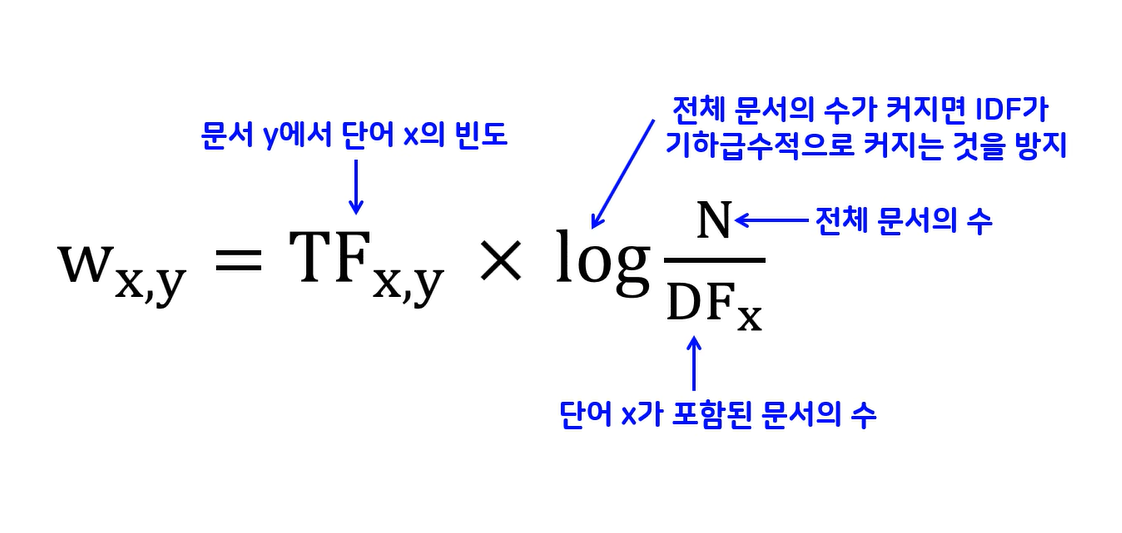